# 5 · Lab: Hong–Ou–Mandel Interference

**Simulation lab, part 1 · Wednesday July 29, 10:30–11:30 · work in pairs**

Today you run linear-optical experiments on a simulated photonic quantum processor, using **Perceval** [Heurtel2023] — the same framework used to program Quandela's real photonic quantum computers. The physics star of this session is the **Hong–Ou–Mandel (HOM) effect** [Hong1987]: two indistinguishable photons meeting on a beamsplitter *always leave together*.

### Learning objectives

1. build and sample a linear-optical circuit in Perceval,
2. predict and verify the two-photon output of a 50:50 beamsplitter,
3. simulate a **HOM dip** and extract its visibility.

*Review reading: [Bouchard2021] in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("perceval") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "perceval-quandela"])

import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
print("perceval", pcvl.__version__)

perceval 1.2.4


## Perceval in 10 minutes

Perceval describes experiments the way an optics lab does:

| concept | Perceval object | example |
|---|---|---|
| photons entering the chip | `BasicState` | `pcvl.BasicState([1, 1])` — one photon in each of 2 modes |
| the optical circuit | `Circuit` + components | `pcvl.BS()` (beamsplitter), `pcvl.PS(phi)` (phase shifter) |
| the machine that runs it | `Processor` | `pcvl.Processor("SLOS", circuit)` |
| taking data | `Sampler` | `sampler.probs()` or `sampler.sample_count(N)` |

A *mode* is one path on the chip (it could also be a polarization or a time bin). `|1,1⟩` means "one photon in the top mode, one in the bottom mode". Let's start with the simplest quantum experiment there is: **one photon on a beamsplitter.**

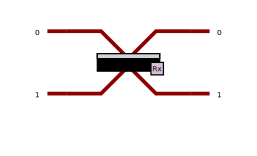

In [2]:
# One photon, one 50:50 beamsplitter.
circuit = pcvl.Circuit(2) // pcvl.BS()      # 2 modes, one beamsplitter
pcvl.pdisplay(circuit)

In [3]:
processor = pcvl.Processor("SLOS", circuit)    # SLOS = exact simulation backend
processor.with_input(pcvl.BasicState([1, 0]))  # photon enters the top mode
processor.min_detected_photons_filter(1)       # keep events with >= 1 detected photon

sampler = pcvl.algorithm.Sampler(processor)
probs = sampler.probs()["results"]
print("exact output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

# ... and what actual repeated single-shot measurements look like:
counts = sampler.sample_count(1000)["results"]
print("\n1000 samples (clicks!):")
for state, c in counts.items():
    print(f"  {state}: {c}")

exact output probabilities:
  |0,1>: 0.500
  |1,0>: 0.500

1000 samples (clicks!):
  |1,0>: 499
  |0,1>: 501


50/50 — each *single* photon takes one output or the other at random (this randomness is quantum: it is the shot noise you met on Monday). So far a classical coin would explain the data.

## The HOM effect: now send in TWO photons

Input $|1,1\rangle$ — one photon in each input port, perfectly indistinguishable. Classical intuition says: each picks a side independently, so 50% of the time they exit on *different* sides (a coincidence).

Quantum mechanics says: the two paths to a coincidence — *both transmit* and *both reflect* — are indistinguishable processes, so their **amplitudes** add. For a 50:50 beamsplitter they cancel *exactly*:

$$P_{\rm coinc} = |t\cdot t - r\cdot r|^2 = \left|\tfrac12 - \tfrac12\right|^2 = 0 .$$

(The minus sign is the beamsplitter's unitarity speaking: the reflected amplitude carries a phase $i$, and $i^2 = -1$.)

In [4]:
# HOM: two indistinguishable photons on the 50:50 beamsplitter.
processor = pcvl.Processor("SLOS", circuit)
processor.with_input(pcvl.BasicState([1, 1]))
processor.min_detected_photons_filter(2)

probs = pcvl.algorithm.Sampler(processor).probs()["results"]
print("two-photon output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

two-photon output probabilities:
  |0,2>: 0.500
  |2,0>: 0.500


**The photons bunch:** always $|2,0\rangle$ or $|0,2\rangle$, *never* $|1,1\rangle$. No coincidences — this is not interference of intensities (it survives any phase between the inputs), it is interference of **two-photon amplitudes**. It only happens because the photons are fully indistinguishable bosons.

## Exercise 1 · Unbalancing the beamsplitter

For a beamsplitter with reflectivity $R$ (and $T = 1-R$), the coincidence probability for $|1,1\rangle$ input is

$$P_{\rm coinc}(R) = (T - R)^2 = (1 - 2R)^2 .$$

**Task:** verify this with Perceval. Scan $R$ from 0 to 1 (say 21 points), get $P(|1,1\rangle)$ at the output for each, plot the simulation as points and the formula as a line.

*API hint:* a beamsplitter with a given reflectivity is `pcvl.BS(theta=pcvl.BS.r_to_theta(R))`.

In [5]:
# YOUR CODE HERE - Exercise 1
R_values = np.linspace(0, 1, 21)


## Exercise 2 · The HOM dip

In the lab you can't just declare photons indistinguishable — you *tune* their overlap, classically, by sliding a delay line: photons that arrive at very different times are perfectly distinguishable (no interference), photons that arrive simultaneously interfere fully. Scanning the delay $\delta\tau$ traces out the famous **HOM dip** in the coincidence rate.

For photons with Gaussian wavepackets of coherence time $\tau_c$, the *indistinguishability* (mode overlap squared) is

$$\mathcal{I}(\delta\tau) = e^{-(\delta\tau/\tau_c)^2},$$

and the coincidence probability at a 50:50 beamsplitter becomes

$$P_{\rm coinc}(\delta\tau) = \tfrac12\left(1 - \mathcal{I}(\delta\tau)\right).$$

In Perceval, partial distinguishability is a property of the photon *source*, set through the noise model:

```python
processor = pcvl.Processor("SLOS", circuit,
                           noise=pcvl.NoiseModel(indistinguishability=I))
```

**Task:**
1. sweep $\mathcal{I}$ from 0 to 1 and record $P(|1,1\rangle)$ — confirm $P = (1-\mathcal{I})/2$;
2. convert to a dip: plot $P_{\rm coinc}$ versus delay $\delta\tau/\tau_c \in [-3, 3]$ using the Gaussian mapping;
3. compute the **visibility** $V = \frac{P_{\max} - P_{\min}}{P_{\max}}$ of your dip. What is $V$ for perfectly indistinguishable photons? What would $V = 0.5$ tell you about a photon-pair source?

In [6]:
# YOUR CODE HERE - Exercise 2
indistinguishability_values = np.linspace(0, 1, 11)


## If you finish early

* Put a phase shifter in one input arm (`pcvl.PS(phi)` before the BS) and show that the HOM dip does **not** depend on the phase — two-photon interference is phase-insensitive (that's how you distinguish it from classical interference in the lab!).
* Three-mode challenge: build a *tritter* (3-mode balanced splitter: `pcvl.Circuit(3)` with three `BS`/`PS` — or `pcvl.GenericInterferometer`) and find the three-photon analog of HOM suppression for $|1,1,1\rangle$.

## Why this matters (5-minute wrap-up before the break)

* **HOM visibility is *the* benchmark of single-photon sources**: quantum dots today reach raw two-photon interference visibilities above 90% — the number to look for in any source paper [Bouchard2021].
* Every **two-qubit gate in linear-optical quantum computing** is built from exactly this interference: photons that don't HOM don't compute. The 2020 boson-sampling quantum-advantage experiment [Zhong2020] is, at heart, 50 photons HOM-interfering in a 100-mode interferometer.
* After the break: we stop *assuming* single photons and *make* them — [`06_Lab_HeraldedFockStates`](06_Lab_HeraldedFockStates.ipynb).

---
---

# Sample solutions

**No peeking during the session.**

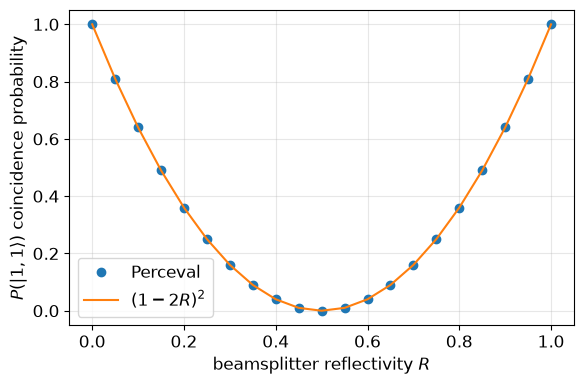

In [7]:
# Solution - Exercise 1
R_values = np.linspace(0, 1, 21)
p_coinc = []
for R in R_values:
    c = pcvl.Circuit(2) // pcvl.BS(theta=pcvl.BS.r_to_theta(R))
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(R_values, p_coinc, "o", label="Perceval")
plt.plot(R_values, (1 - 2 * R_values) ** 2, "-", label="$(1-2R)^2$")
plt.xlabel("beamsplitter reflectivity $R$")
plt.ylabel(r"$P(|1,1\rangle)$ coincidence probability")
plt.legend(); plt.tight_layout(); plt.show()

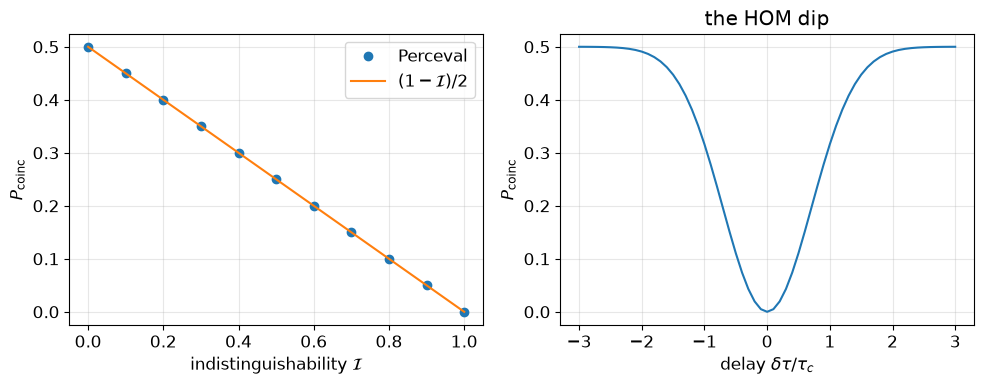

dip visibility V = 1.000
V = 1 for perfectly indistinguishable photons;
V = 0.5 is the classical limit for intensity-correlated fields -
a source with V = 0.5 shows no quantum interference at all.


In [8]:
# Solution - Exercise 2
circuit = pcvl.Circuit(2) // pcvl.BS()

# (1) coincidences vs indistinguishability
I_values = np.linspace(0, 1, 11)
p_coinc = []
for I in I_values:
    proc = pcvl.Processor("SLOS", circuit,
                          noise=pcvl.NoiseModel(indistinguishability=I))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(sum(p for st, p in res.items()
                       if st[0] == 1 and st[1] == 1))
p_coinc = np.array(p_coinc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(I_values, p_coinc, "o", label="Perceval")
ax1.plot(I_values, (1 - I_values) / 2, "-", label=r"$(1-\mathcal{I})/2$")
ax1.set_xlabel(r"indistinguishability $\mathcal{I}$")
ax1.set_ylabel(r"$P_{\rm coinc}$")
ax1.legend()

# (2) the dip vs delay, Gaussian wavepackets
delay = np.linspace(-3, 3, 61)                    # delta_tau / tau_c
I_of_delay = np.exp(-delay**2)
# interpolate the simulated P(I) onto the delay axis:
p_dip = np.interp(I_of_delay, I_values, p_coinc)
ax2.plot(delay, p_dip, "-")
ax2.set_xlabel(r"delay $\delta\tau / \tau_c$")
ax2.set_ylabel(r"$P_{\rm coinc}$")
ax2.set_title("the HOM dip")
plt.tight_layout(); plt.show()

# (3) visibility
V = (p_dip.max() - p_dip.min()) / p_dip.max()
print(f"dip visibility V = {V:.3f}")
print("V = 1 for perfectly indistinguishable photons;")
print("V = 0.5 is the classical limit for intensity-correlated fields -")
print("a source with V = 0.5 shows no quantum interference at all.")